# Extract Recovered Symbolic Model

In [1]:
import sympy as sp
import torch
import dill
from pathlib import Path
# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------
SAVE_PATH = Path("models/frf_model_full.pt")
device = 'cpu'

ckpt = torch.load(
    SAVE_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

# ------------------------------------------------------------
# symbolic variables
# ------------------------------------------------------------
f = sp.Symbol("f")
sin_phi = sp.Symbol(r"\sin{\phi}")
cos_phi = sp.Symbol(r"\cos{\phi}")
mu = sp.Symbol(r"\boldsymbol{\mu}")

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def coef(w: torch.Tensor, decimals: int = 2):
    val = float(w.real.detach().cpu().item())
    return round(val, decimals)

# ------------------------------------------------------------
# build expression
# ------------------------------------------------------------
a = coef(model.a)
b = coef(model.b)

expr = a * f + b

for i, block in enumerate(model.resonators, start=1):

    c = coef(block.c)
    d = coef(block.d)
    g = coef(block.g)

    g_i = sp.Symbol(f"g_{i}")

    expr = expr + c / ((d * f - g_i) ** 2 + g)

# ------------------------------------------------------------
# equation
# ------------------------------------------------------------
Hhat = sp.Symbol(r"\hat{H}")
lhs = sp.Function(Hhat)(f, sin_phi, cos_phi, mu)

eq = sp.Eq(lhs, expr)

# plain output
print(eq)

# LaTeX output
latex_str = sp.latex(eq)

print("\nLaTeX:\n")
print(r"\begin{equation}")
print(latex_str)
print(r"\end{equation}")

Eq(\hat{H}(f, \sin{\phi}, \cos{\phi}, \boldsymbol{\mu}), 2.55*f + 0.34 + 0.13/((1.58*f - g_6)**2 - 0.35) + 0.18/((-0.06*f - g_4)**2 + 0.59) - 1.16/((-0.06*f - g_2)**2 + 0.81) + 0.75/((-0.29*f - g_1)**2 + 0.47) - 0.03/(-0.14*f - g_3)**2 - 0.47/(-1.46*f - g_5)**2)

LaTeX:

\begin{equation}
\hat{H}{\left(f,\sin{\phi},\cos{\phi},\boldsymbol{\mu} \right)} = 2.55 f + 0.34 + \frac{0.13}{\left(1.58 f - g_{6}\right)^{2} - 0.35} + \frac{0.18}{\left(- 0.06 f - g_{4}\right)^{2} + 0.59} - \frac{1.16}{\left(- 0.06 f - g_{2}\right)^{2} + 0.81} + \frac{0.75}{\left(- 0.29 f - g_{1}\right)^{2} + 0.47} - \frac{0.03}{\left(- 0.14 f - g_{3}\right)^{2}} - \frac{0.47}{\left(- 1.46 f - g_{5}\right)^{2}}
\end{equation}


In [2]:
eq

Eq(\hat{H}(f, \sin{\phi}, \cos{\phi}, \boldsymbol{\mu}), 2.55*f + 0.34 + 0.13/((1.58*f - g_6)**2 - 0.35) + 0.18/((-0.06*f - g_4)**2 + 0.59) - 1.16/((-0.06*f - g_2)**2 + 0.81) + 0.75/((-0.29*f - g_1)**2 + 0.47) - 0.03/(-0.14*f - g_3)**2 - 0.47/(-1.46*f - g_5)**2)

In [3]:
symbol_map = {}

symbol_map = {
    "z1": sp.Symbol(r"\mu_{1}"),
    "z2": sp.Symbol(r"\mu_{2}"),
    "z3": sp.Symbol(r"\mu_{3}"),
    "z4": sp.Symbol(r"\mu_{4}"),
    "z5": sp.Symbol(r"\mu_{5}"),
    "z6": sp.Symbol(r"\mu_{6}"),
}

symbolic_inputs_aux = [
    symbol_map["z1"],
    symbol_map["z2"],
    symbol_map["z3"],
    symbol_map["z4"],
    symbol_map["z5"],
    symbol_map["z6"],
]


for i, block in enumerate(model.resonators, start=1):

    g_expr = block.eql.get_symbolic_expression(
        symbolic_inputs_aux,
        rounding_decimals=2,
        use_imag=False,
    )

    print(f"g_{i} = {g_expr}\n")

    latex_expr = sp.latex(g_expr)

    print("LaTeX:")
    print(rf"g_{{{i}}} = {latex_expr}")


g_1 = 0.02*\mu_{6}**0.5 - 0.33*\mu_{6}

LaTeX:
g_{1} = 0.02 \mu_{6}^{0.5} - 0.33 \mu_{6}
g_2 = -0.23*\mu_{4} + 0.3*\mu_{6} - 0.14

LaTeX:
g_{2} = - 0.23 \mu_{4} + 0.3 \mu_{6} - 0.14
g_3 = 0.06*\mu_{6} - 0.17

LaTeX:
g_{3} = 0.06 \mu_{6} - 0.17
g_4 = -0.22*\mu_{6}

LaTeX:
g_{4} = - 0.22 \mu_{6}
g_5 = 0.08*\mu_{4} - 0.62*\mu_{6}**0.5 - 0.77*\mu_{6} - 0.39

LaTeX:
g_{5} = 0.08 \mu_{4} - 0.62 \mu_{6}^{0.5} - 0.77 \mu_{6} - 0.39
g_6 = 0

LaTeX:
g_{6} = 0


# Visualize FRF predictions

Loaded model from: models/frf_model_full.pt
Healthy file: P-1.txt
Damaged file: P-1-2.txt


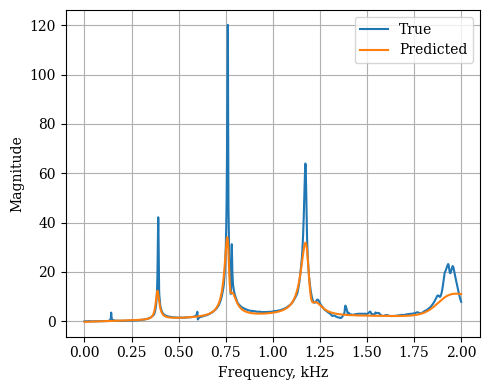

In [14]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List

import dill
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

HEALTHY_FOLDER = FRF_FOLDERS["healthy"]
DAMAGED_FOLDER = FRF_FOLDERS["damage_5.92"]

MASS_POS_XLSX = DATA / "Mass position.xlsx"
MASS_POS_SHEET = "Posições aleatórias"

MODEL_PATH = Path("models/frf_model_full.pt")


# ============================================================
# Config
# ============================================================
FEATURE_TOKENS: List[str] = ["f", "z1", "z2", "z3", "z4", "z5", "z6"]
NOMINAL_MASS = 1.0
device = torch.device("cpu")


# ============================================================
# Load model
# ============================================================
ckpt = torch.load(
    MODEL_PATH,
    map_location=device,
    pickle_module=dill,
    weights_only=False,
)

model = ckpt["model"].to(device)
model.eval()

print("Loaded model from:", MODEL_PATH)


# ============================================================
# Robust FRF TXT reader
# ============================================================
_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")
_RE_FILE = re.compile(r"^P-(\d+)(?:-(\d+))?$")


def read_frf_txt(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    text = path.read_bytes().decode("latin-1", errors="ignore")

    f_list, m_list, p_list = [], [], []

    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue

        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue

        f = float(nums[0])
        mag = float(nums[1])
        ph = float(nums[2])

        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue

        f_list.append(f)
        m_list.append(mag)
        p_list.append(ph)

    if not f_list:
        raise ValueError(f"No numeric data parsed from {path}")

    f = np.asarray(f_list, dtype=float)
    mag = np.asarray(m_list, dtype=float)
    ph = np.asarray(p_list, dtype=float)

    idx = np.argsort(f)
    return f[idx], mag[idx], ph[idx]


def parse_file_id(fp: Path) -> tuple[int, int]:
    m = _RE_FILE.match(fp.stem)
    if not m:
        raise ValueError(f"Unexpected FRF filename: {fp.name}")
    sample = int(m.group(1))
    suffix = int(m.group(2)) if m.group(2) is not None else 0
    return sample, suffix


# ============================================================
# Mass positions
# ============================================================
def load_mass_positions(xlsx_path: Path, sheet_name: str) -> np.ndarray:
    df0 = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    cols_pos = [
        "Masses position values [mm]",
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4",
        "Unnamed: 5",
        "Unnamed: 6",
    ]
    names = [str(df0.loc[0, c]).strip() for c in cols_pos]

    df = df0.loc[1:, ["Samples"] + cols_pos].copy()
    df = df.rename(columns={"Samples": "sample", **{c: n for c, n in zip(cols_pos, names)}})

    df["sample"] = pd.to_numeric(df["sample"], errors="coerce").astype("Int64")
    for n in names:
        df[n] = pd.to_numeric(df[n], errors="coerce")

    df = df.dropna(subset=["sample"]).astype({"sample": int})
    df = df[["sample"] + names].reset_index(drop=True)

    max_sample = int(df["sample"].max())
    pos = np.full((max_sample + 1, 6), np.nan, dtype=float)

    for _, r in df.iterrows():
        s = int(r["sample"])
        pos[s, :] = [float(r[n]) for n in names]

    return pos


POS_BY_SAMPLE = load_mass_positions(MASS_POS_XLSX, MASS_POS_SHEET)


# ============================================================
# Feature construction: EXACTLY as in training
# ============================================================
def present_mask(cond: str) -> np.ndarray:
    mask = np.ones(6, dtype=float)
    if cond == "damage_2.96":
        mask[0] = 0.0
    elif cond == "damage_5.92":
        mask[0] = 0.0
        mask[2] = 0.0
    elif cond == "damage_8.87":
        mask[0] = 0.0
        mask[2] = 0.0
        mask[4] = 0.0
    return mask


def db_to_linear_mag(mag_db: np.ndarray) -> np.ndarray:
    return np.power(10.0, mag_db / 20.0)


def build_feature_matrix(
    *,
    f: np.ndarray,
    mag_db: np.ndarray,
    ph_deg: np.ndarray,
    cond: str,
    sample: int,
    feature_tokens: List[str],
) -> tuple[np.ndarray, np.ndarray]:
    phi = np.deg2rad(ph_deg)
    sinp = np.sin(phi)
    cosp = np.cos(phi)

    pos = POS_BY_SAMPLE[sample, :].astype(float)
    if not np.isfinite(pos).all():
        raise ValueError(f"Missing positions for sample={sample} in {MASS_POS_XLSX}")

    m = NOMINAL_MASS * present_mask(cond)
    z = (m * pos).astype(float)

    z_abs_max = np.max(np.abs(z))
    if z_abs_max > 0.0:
        z = z / z_abs_max

    feature_bank: Dict[str, np.ndarray] = {
        "f": (f / 1000.0).astype(np.float32),
        "sin_phase": sinp.astype(np.float32),
        "cos_phase": cosp.astype(np.float32),
        "z1": np.full_like(f, z[0], dtype=np.float32),
        "z2": np.full_like(f, z[1], dtype=np.float32),
        "z3": np.full_like(f, z[2], dtype=np.float32),
        "z4": np.full_like(f, z[3], dtype=np.float32),
        "z5": np.full_like(f, z[4], dtype=np.float32),
        "z6": np.full_like(f, z[5], dtype=np.float32),
    }

    missing = [t for t in feature_tokens if t not in feature_bank]
    if missing:
        raise ValueError(f"Unknown feature tokens: {missing}")

    X = np.concatenate(
        [feature_bank[t].reshape(-1, 1) for t in feature_tokens],
        axis=1,
    ).astype(np.float32)

    y = db_to_linear_mag(mag_db).astype(np.float32).reshape(-1, 1)

    return X, y


# ============================================================
# Prediction helper
# ============================================================
def predict_curve(fp: Path, cond: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    sample, _ = parse_file_id(fp)
    f, mag_db, ph_deg = read_frf_txt(fp)

    X, y_lin = build_feature_matrix(
        f=f,
        mag_db=mag_db,
        ph_deg=ph_deg,
        cond=cond,
        sample=sample,
        feature_tokens=FEATURE_TOKENS,
    )

    f_idx = FEATURE_TOKENS.index("f")
    f_plot = X[:, f_idx]

    with torch.no_grad():
        Xc = torch.from_numpy(X).float().to(device)
        pred = model(Xc)

        pred_np = pred.detach().cpu().numpy()
        if np.iscomplexobj(pred_np):
            pred_np = pred_np.real

        pred_lin = pred_np.reshape(-1)

    y_lin = y_lin.reshape(-1)

    order = np.argsort(f_plot)
    return f_plot[order], y_lin[order], pred_lin[order]


# ============================================================
# Select one healthy and one damaged file
# ============================================================
healthy_file = sorted(HEALTHY_FOLDER.glob("*.txt"))[0]
damaged_file = sorted(DAMAGED_FOLDER.glob("*.txt"))[0]

print("Healthy file:", healthy_file.name)
print("Damaged file:", damaged_file.name)



# ============================================================
# Damaged plot (linear)
# ============================================================
f_d, y_d, pred_d = predict_curve(damaged_file, "damage_5.92")

import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"

plt.figure(figsize=(5,4))
plt.plot(f_d, y_d, label="True")
plt.plot(f_d, pred_d, label="Predicted")
plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('figures/frf_prediction.pdf', bbox_inches='tight')
plt.show()

# Peak Shift Comparison

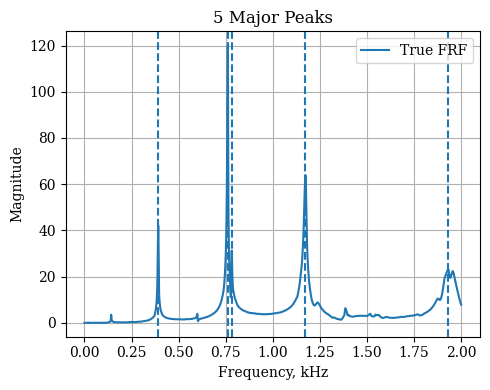

In [17]:
# ============================================================
# Detect major peaks on the TRUE FRF
# ============================================================
from scipy.signal import find_peaks

N_PEAKS = 5

# detect all candidate peaks
peak_idx, _ = find_peaks(y_d)

# sort peaks by amplitude
peak_amplitudes = y_d[peak_idx]
order = np.argsort(peak_amplitudes)[::-1]

# select N largest peaks
top_idx = peak_idx[order[:N_PEAKS]]

# sort them by frequency for nicer plotting
top_idx = np.sort(top_idx)

peak_freqs = f_d[top_idx]
peak_vals = y_d[top_idx]


# ============================================================
# Plot FRF with detected peaks
# ============================================================
plt.figure(figsize=(5,4))

plt.plot(f_d, y_d, label="True FRF")

for f_peak in peak_freqs:
    plt.axvline(f_peak, linestyle="--")

plt.xlabel("Frequency, kHz")
plt.ylabel("Magnitude")
plt.title("5 Major Peaks")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()